# Global Layoffs Analysis

This project analyzes global layoffs between 2020 and 2026 to identify trends across companies, countries, industries, and time periods. The goal is to understand which areas were most affected and how layoff activity changed over time.

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Project Objective

Analyze global layoffs between 2020 and 2026 to identify trends across companies, countries, industries, and time periods.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("layoffs.csv")

## Data Understanding

In [4]:
df.head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Lastminute,"Amsterdam, Non-U.S.",400.0,6/17/2026,0.25,Travel,https://res.cloudinary.com/lastminute-contenth...,Post-IPO,NaN,Netherlands,6/19/2026
1,Optimove,"Tel Aviv, Non-U.S.",NaN,6/17/2026,0.10,Marketing,https://www.intergameonline.com/igaming/news/o...,Series A,20.0,Israel,6/19/2026
2,Robinhood,SF Bay Area,290.0,6/16/2026,0.10,Finance,https://www.forbes.com/sites/tylerroush/2026/0...,Post-IPO,6200.0,United States,6/16/2026
3,Artlist,"Tel Aviv, Non-U.S.",200.0,6/16/2026,0.40,Media,https://www.calcalistech.com/ctechnews/article...,Unknown,48.0,Israel,6/16/2026
4,FNZ,"London, Non-U.S.",NaN,6/16/2026,NaN,Finance,https://citywire.com/new-model-adviser/news/ex...,Private Equity,3500.0,United Kingdom,6/16/2026
5,Matter Labs,"Berlin, Non-U.S.",NaN,6/16/2026,NaN,Crypto,https://x.com/gluk64/status/2066964567884747146,Unknown,308.0,Germany,6/19/2026
6,Rackspace,San Antonio,NaN,6/16/2026,0.15,Data,https://www.bizjournals.com/sanantonio/news/20...,Acquired,17.0,United States,6/19/2026
7,Rivian,Detroit,NaN,6/16/2026,0.02,Transportation,https://techcrunch.com/2026/06/16/rivian-cuts-...,Post-IPO,10700.0,United States,6/16/2026
8,Pleo,"Copenhagen, Non-U.S.",50.0,6/12/2026,NaN,Finance,https://tech.eu/2026/06/12/pleo-undertakes-fre...,Series C,428.0,Denmark,6/12/2026
9,ServiceNow,SF Bay Area,54.0,6/11/2026,NaN,Support,https://www.siliconvalley.com/2026/06/11/tech-...,Post-IPO,84.0,United States,6/12/2026


In [5]:
df.shape

(4469, 11)

In [6]:
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4469 entries, 0 to 4468
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4469 non-null   object 
 1   location             4468 non-null   object 
 2   total_laid_off       2928 non-null   float64
 3   date                 4469 non-null   object 
 4   percentage_laid_off  2806 non-null   float64
 5   industry             4467 non-null   object 
 6   source               4466 non-null   object 
 7   stage                4464 non-null   object 
 8   funds_raised         3948 non-null   float64
 9   country              4467 non-null   object 
 10  date_added           4469 non-null   object 
dtypes: float64(3), object(8)
memory usage: 384.2+ KB


## Data Cleaning

In [8]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1541
date                      0
percentage_laid_off    1663
industry                  2
source                    3
stage                     5
funds_raised            521
country                   2
date_added                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df["date"] = pd.to_datetime(df["date"])

## Top 10 Companies Analysis

In [16]:
df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(10)

company
Amazon        58124.0
Intel         43115.0
Meta          35700.0
Oracle        31294.0
Microsoft     30055.0
Dell          23650.0
Cisco         18521.0
Salesforce    16611.0
Tesla         14500.0
Google        13697.0
Name: total_laid_off, dtype: float64

## Top 10 Countries Analysis

In [17]:
df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False).head(10)

country
United States     657891.0
India              66289.0
Germany            32055.0
United Kingdom     24594.0
Netherlands        21975.0
Sweden             20379.0
Canada             16068.0
Israel             14819.0
Brazil             11939.0
China               8190.0
Name: total_laid_off, dtype: float64

## Top 10 Industries Analysis

In [18]:
df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)

industry
Other             119830.0
Retail            106706.0
Hardware          106261.0
Consumer           97007.0
Finance            69512.0
Transportation     66002.0
Food               52101.0
Healthcare         39462.0
Infrastructure     24835.0
Travel             24140.0
Name: total_laid_off, dtype: float64

## Visualizations

In [20]:
import matplotlib.pyplot as plt

In [22]:
top10_companies = (
    df.groupby("company")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

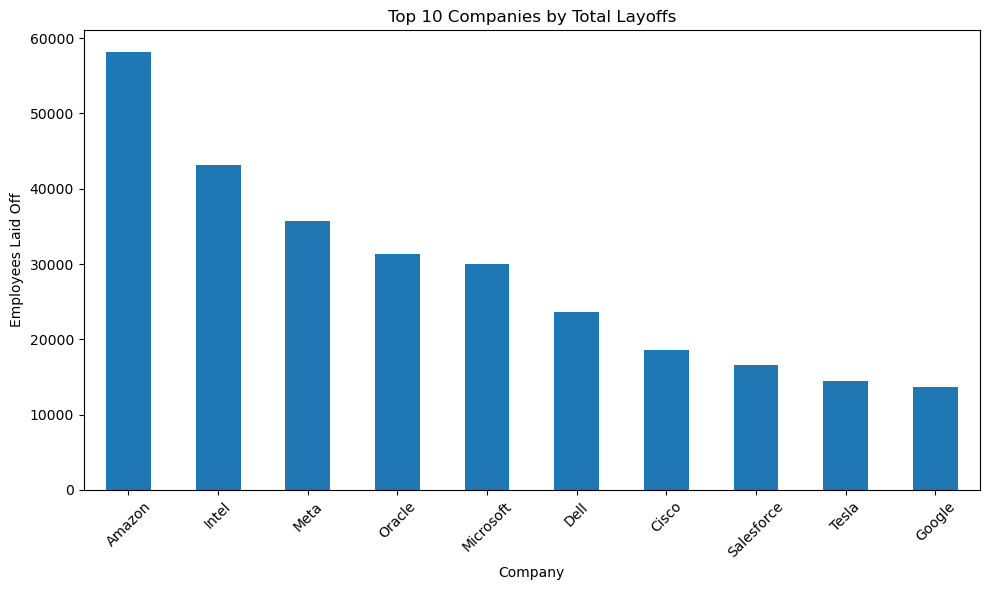

In [34]:
plt.figure(figsize=(10,6))

top10_companies.plot(kind="bar")

plt.title("Top 10 Companies by Total Layoffs")

plt.xlabel("Company")

plt.ylabel("Employees Laid Off")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top10_companies.png")

plt.show()

In [24]:
top10_countries = (
    df.groupby("country")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

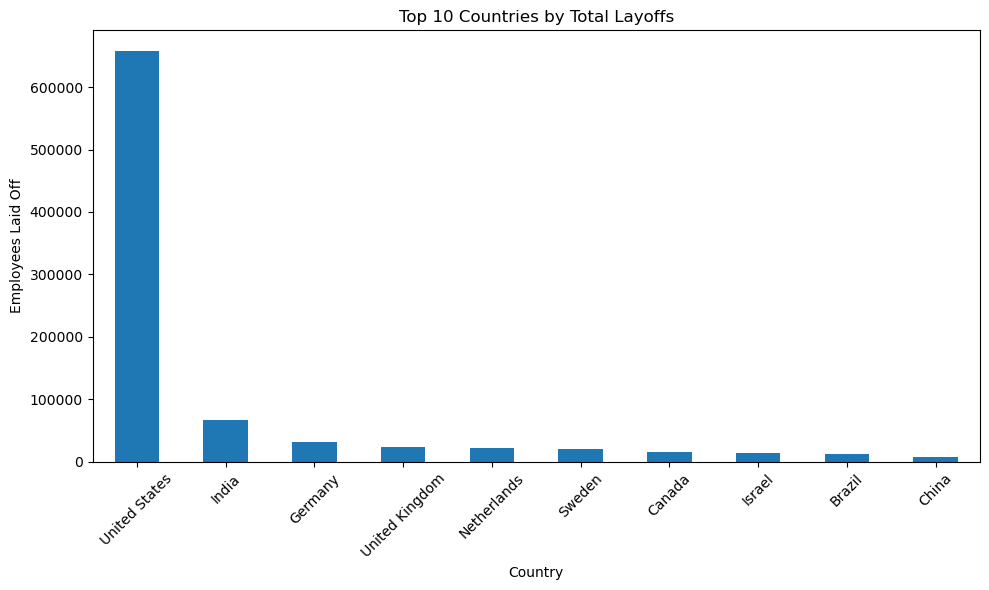

In [35]:
plt.figure(figsize=(10,6))

top10_countries.plot(kind="bar")

plt.title("Top 10 Countries by Total Layoffs")

plt.xlabel("Country")

plt.ylabel("Employees Laid Off")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top10_countries.png")

plt.show()

In [26]:
top10_industries = (
    df.groupby("industry")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

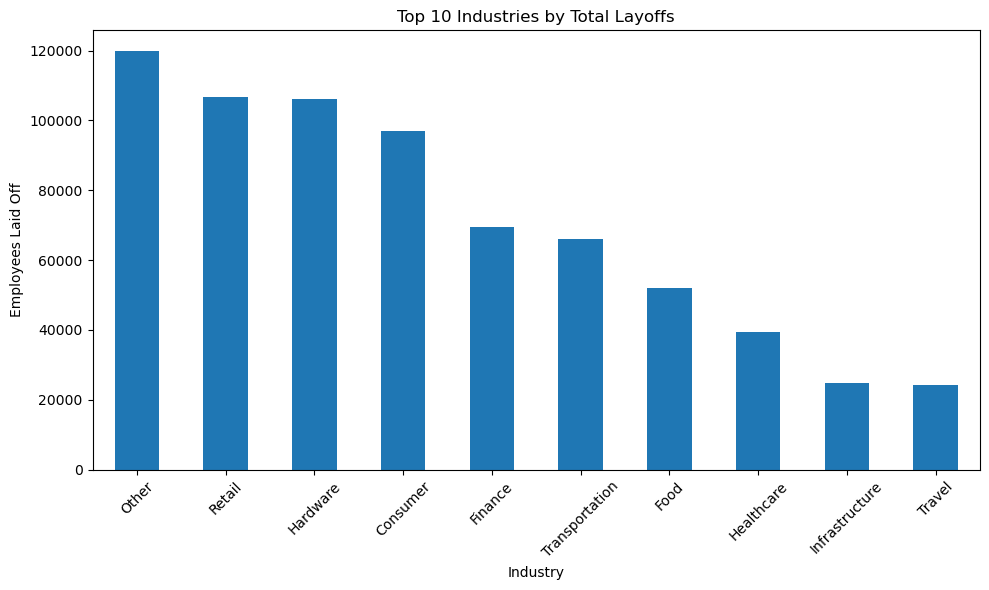

In [36]:
plt.figure(figsize=(10,6))

top10_industries.plot(kind="bar")

plt.title("Top 10 Industries by Total Layoffs")

plt.xlabel("Industry")

plt.ylabel("Employees Laid Off")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top10_industries.png")

plt.show()

## Layoffs Over Time Analysis

In [30]:
monthly_layoffs = (
    df.groupby(df["date"].dt.to_period("M"))["total_laid_off"]
    .sum()
)

In [31]:
monthly_layoffs

date
2020-03     9628.0
2020-04    26710.0
2020-05    25804.0
2020-06     7627.0
2020-07     7112.0
            ...   
2026-02    11269.0
2026-03    46593.0
2026-04     5085.0
2026-05    28934.0
2026-06     2398.0
Freq: M, Name: total_laid_off, Length: 76, dtype: float64

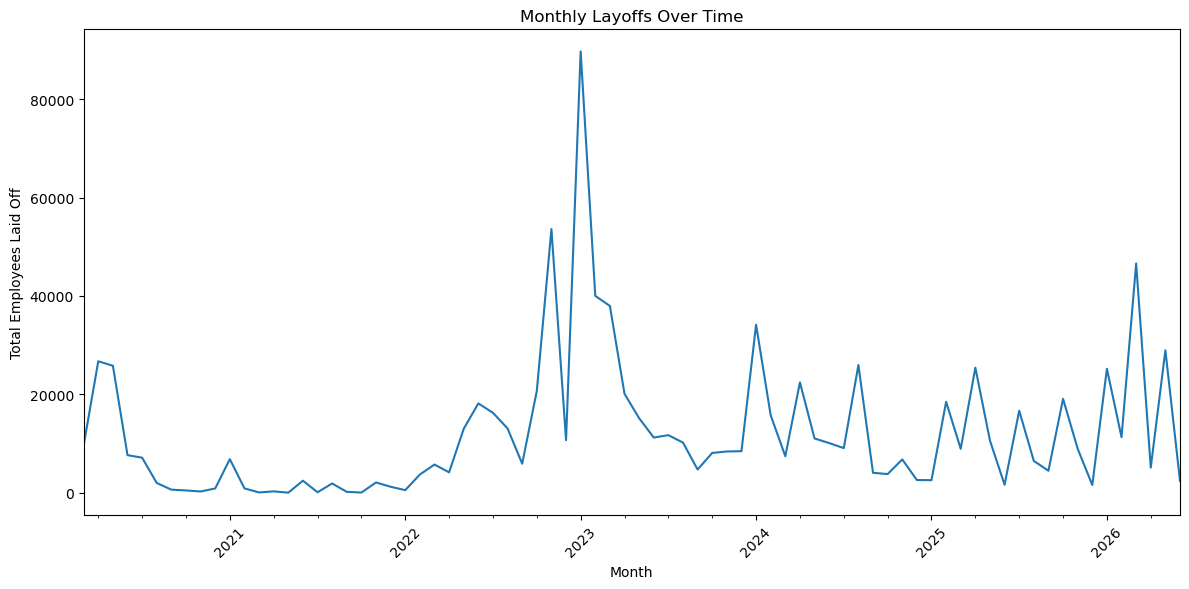

In [37]:
plt.figure(figsize=(12,6))

monthly_layoffs.plot(kind="line")

plt.title("Monthly Layoffs Over Time")

plt.xlabel("Month")

plt.ylabel("Total Employees Laid Off")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("monthly_layoffs.png")

plt.show()

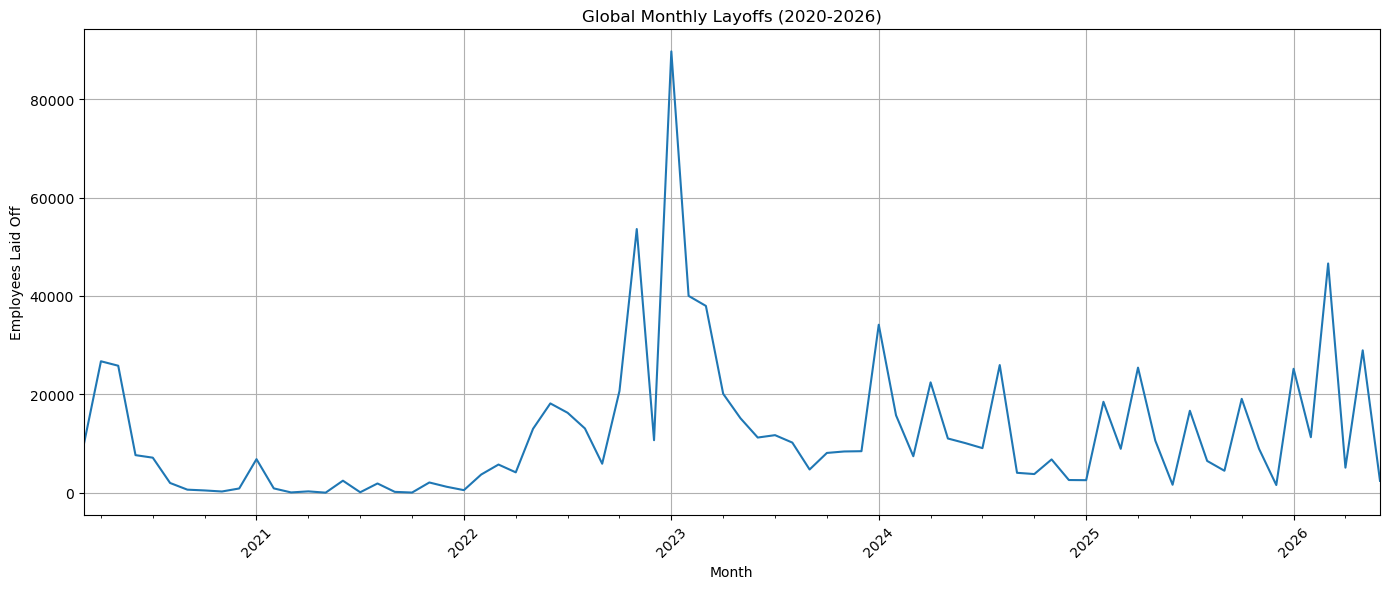

In [38]:
plt.figure(figsize=(14,6))

monthly_layoffs.plot()

plt.title("Global Monthly Layoffs (2020-2026)")

plt.xlabel("Month")

plt.ylabel("Employees Laid Off")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("monthly_layoffs1.png")

plt.show()

## Key Insights

### Key Findings

#### Companies

- Amazon had the highest number of layoffs (58,124).
- Several large technology companies dominated the top rankings.

#### Countries

- The United States had significantly more layoffs than any other country.
- The dataset appears heavily concentrated on US companies.

#### Industries

- Retail, Hardware, and Consumer industries were among the most affected.
- The "Other" category was unusually large and may contain many different industries.

#### Time Analysis

- Layoffs peaked around late 2022 and early 2023.
- Layoff activity remained volatile after 2023.

## Skills Demonstrated

- Loading and exploring datasets with Pandas
- Cleaning and preparing data for analysis
- Grouping and aggregating data using groupby()
- Creating data visualizations with Matplotlib
- Performing time series analysis
- Generating business insights from data